Data is comming from the archive http://www.laurent-duval.eu/opus-dual-spls-sparse-pls/Data-dual-sPLS-NIR-near-infrared-spectra-density/matrixXYNir-CSV-dual-sparse-pls.7z (see **Dataset of near-infrared (NIR) spectral data for prediction of organic matter and total carbon in agricultural soil using homemade NIR spectrometer**). Like the paper said, X matrix is tranformed using the Savitzky–Golay filter before use. Here we introduce Dual-sPLS performance using *RMSE* metric for different norms on real data (NIR dataset). Norms $\Omega$ includes :

* Lasso (*lasso.py*)
* Ridge (*ridge.py*)
* GLA (*GLA.py*)
* GLB (*GLB.py*)
* GLC (*GLC.py*)
* $\mathcal{l}_2$ norm (*LS.py*)

In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import sys
from pathlib import Path
import seaborn as sns 
import matplotlib.pyplot as plt
import matplotlib.cm     as cm
import matplotlib.colors as colors


from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics         import mean_squared_error
from sklearn.cluster         import AgglomerativeClustering

# Dual-sPLS library - norms
from dual_spls.lasso import dual_spls_lasso
from dual_spls.ridge import d_spls_ridge
from dual_spls.GLA   import dual_spls_gla_random
from dual_spls.GLB   import dual_spls_glb
from dual_spls.GLC   import dual_spls_glc
from dual_spls.LS    import d_spls_ls

sns.set_style("darkgrid")

In [2]:
# Import dataset
X = pd.read_csv(
    "../data/matrixXNirSpectrumDerivative.csv"
)
X.head()

,0.00293123424053193,0.00255436311875071,0.0020018325320312,0.00196149115051542,0.00192856660911015,0.0026838980615139,0.00185868952955519,0.00212735352771622,0.00210245932851519,0.00222007227795464,...,0.00218016813908305,0.00187072977423667,0.00272921706948961,0.00301864594221115,0.00199910349079539,0.00191627740859985,0.00268596070153373,0.00232852495142393,0.00253164342471531,0.00188808962702751
0,0.002981,0.002625,0.002059,0.002022,0.001990,0.002611,0.001919,0.002184,0.002161,0.002267,...,0.002229,0.001931,0.002490,0.002956,0.002058,0.001977,0.002400,0.002340,0.002562,0.001951
1,0.003050,0.002717,0.002144,0.002109,0.002077,0.002578,0.002006,0.002266,0.002243,0.002340,...,0.002302,0.002017,0.002316,0.002925,0.002146,0.002065,0.002189,0.002380,0.002616,0.002038
2,0.003139,0.002831,0.002253,0.002213,0.002184,0.002584,0.002115,0.002367,0.002342,0.002433,...,0.002399,0.002127,0.002213,0.002929,0.002257,0.002174,0.002058,0.002448,0.002693,0.002147
3,0.003246,0.002962,0.002377,0.002333,0.002307,0.002632,0.002241,0.002483,0.002455,0.002542,...,0.002510,0.002253,0.002180,0.002969,0.002383,0.002299,0.002007,0.002540,0.002795,0.002272
4,0.003365,0.003105,0.002510,0.002468,0.002444,0.002715,0.002380,0.002614,0.002584,0.002666,...,0.002634,0.002391,0.002209,0.003042,0.002518,0.002436,0.002026,0.002651,0.002918,0.002409


In [3]:
y = pd.read_csv("../data/matrixYNirPropertyDensityNormalized.csv", header=None)
y.head()

,0,1,2,3,4,5,6,7,8,9,...,198,199,200,201,202,203,204,205,206,207
0,0.536704,0.616918,0.848809,0.894507,0.899854,0.268838,0.906174,0.794361,0.854157,0.755955,...,0.782207,0.90666,0.129315,0.337385,0.870685,0.90034,0.085561,0.506077,0.609626,0.913952


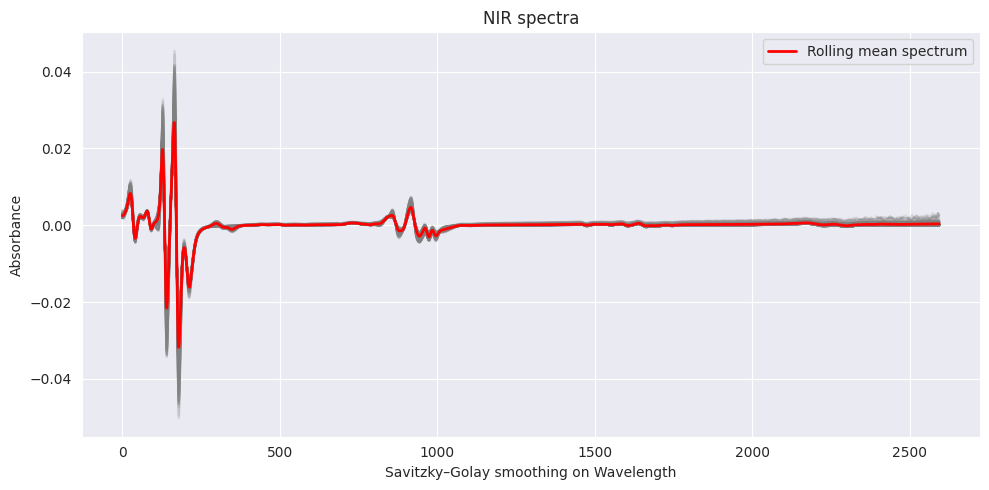

In [5]:
# Data presentation

# ----------- Data (adapted to the lib) ----------- #
X = pd.read_csv(
    "../data/matrixXNirSpectrumDerivative.csv",
     header=None
).T.values
y = pd.read_csv(
    "../data/matrixYNirPropertyDensityNormalized.csv",
    header=None
).values.ravel()

# X : (n_samples, n_wavelengths)
# wavelengths : optionnel (sinon indices)
wavelengths = np.arange(X.shape[1])

plt.figure(figsize=(10, 5))

for i in range(X.shape[0]):
    plt.plot(wavelengths, X[i, :], color="gray", alpha=0.2)

plt.plot(wavelengths, X.mean(axis=0), color="red", linewidth=2, label="Rolling mean spectrum")

plt.xlabel("Savitzky–Golay smoothing on Wavelength")
plt.ylabel("Absorbance")
plt.title("NIR spectra")
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
# Initialization

def cv_rmse(model_fun, X, y, **kwargs):
    rmses = []

    for train_idx, test_idx in kf.split(X):
        Xtr, Xte = X[train_idx], X[test_idx]
        ytr, yte = y[train_idx], y[test_idx]

        try:
            model = model_fun(Xtr, ytr, n_components=n_comp, **kwargs)

            y_pred = (
                (Xte - model["Xmean"])
                @ model["Bhat"][:, -1]
                + model["intercept"][-1]
            )

            # For divergent models
            if not np.all(np.isfinite(y_pred)):
                return np.inf, None

            rmse = np.sqrt(mean_squared_error(yte, y_pred))
            rmses.append(rmse)

        except Exception:
            return np.inf, None

    return np.mean(rmses), model

# ----------- Init for grid search and K fold (K=5) ----------- #
kf = KFold(n_splits=5, shuffle=True, random_state=42)

best_score = np.inf
best_models = {}
best_params = {}

# ----------- Params ----------- #

n_comp = 6
labels = AgglomerativeClustering(n_clusters=25).fit(X.T).labels_  # for GL*
indG = labels + 1  # 1-based groups vector

# Sparsity params
nG = indG.max()    # groups number. same for all GL*

ppnu_grid = np.linspace(0.01, 1, 2)
nu2_grid = np.logspace(-3, 1, 5)         # For Ridge
gamma_grid = np.linspace(0.01, 1.0, 2)  # For GLC

In [5]:
# Hyperparameter tunning using grid search and 5 fold cross - validation

####################
#### LASSO #########
####################

best_rmse = np.inf

for ppnu in ppnu_grid:

    print(f"------------- Grid search - ppnu = {ppnu} -------------")
    rmse, model = cv_rmse(
        dual_spls_lasso, X, y, ppnu=ppnu
    )
    if rmse < best_rmse:
        best_rmse = rmse
        best_models["Lasso"] = {
            "model": model,
            "rmse": rmse,
            "params": {"ppnu": ppnu}
        }

####################
#### RIDGE #########
####################

best_rmse = np.inf

for ppnu in ppnu_grid:
    for nu2 in nu2_grid:

        print(f"------------- Grid search - ppnu = {ppnu}, nu = {nu2} -------------")
        
        rmse, model = cv_rmse(
            d_spls_ridge,
            X, y,
            ppnu=ppnu,
            nu2=nu2
        )

        if rmse < best_rmse:
            best_rmse = rmse
            best_models["Ridge"] = {
                "model": model,
                "rmse": rmse,
                "params": {
                    "ppnu": ppnu,
                    "nu2": nu2
                }
            }

            
####################
#### LS (L2) #######
####################

best_rmse = np.inf

for ppnu in ppnu_grid:

    print(f"------------- Grid search - ppnu = {ppnu} -------------")
    rmse, model = cv_rmse(
        d_spls_ls, X, y, ppnu=ppnu
    )
    if rmse < best_rmse:
        best_rmse = rmse
        best_models["LS"] = {
            "model": model,
            "rmse": rmse,
            "params": {"ppnu": ppnu}
        }

####################
#### GLA ###########
####################

best_rmse = np.inf

for ppnu in ppnu_grid:

    print(f"------------- Grid search - ppnu = {ppnu} -------------")
    rmse, model = cv_rmse(
        dual_spls_gla_random,
        X, y,
        ppnu=np.repeat(ppnu, nG),
        indG=indG,
        verbose=False
    )
    if rmse < best_rmse:
        best_rmse = rmse
        best_models["GLA"] = {
            "model": model,
            "rmse": rmse,
            "params": {"ppnu": ppnu}
        }

####################
#### GLB ###########
####################

best_rmse = np.inf

for ppnu in ppnu_grid:

    print(f"------------- Grid search - ppnu = {ppnu} -------------")
    rmse, model = cv_rmse(
        dual_spls_glb,
        X, y,
        ppnu=np.repeat(ppnu, nG),
        indG=indG,
        verbose=False
    )
    if rmse < best_rmse:
        best_rmse = rmse
        best_models["GLB"] = {
            "model": model,
            "rmse": rmse,
            "params": {"ppnu": ppnu}
        }

####################
#### GLC ###########
####################

best_rmse = np.inf

for ppnu in ppnu_grid:
    for gamma in gamma_grid:

        print(f"------------- Grid search - ppnu = {ppnu}, gamma = {gamma} -------------")
        gamma_vec = np.repeat(gamma, nG)
        gamma_vec /= gamma_vec.sum()

        rmse, model = cv_rmse(
            dual_spls_glc,
            X, y,
            ppnu=np.repeat(ppnu, nG),
            indG=indG,
            gamma=gamma_vec,
            verbose=False
        )

        if rmse < best_rmse:
            best_rmse = rmse
            best_models["GLC"] = {
                "model": model,
                "rmse": rmse,
                "params": {"ppnu": ppnu, "gamma": gamma}
            }

------------- Grid search - ppnu = 0.01 -------------
Dual PLS Lasso ic=1 lambda1=0.0002 mu=1.0077 nu=0.00021867345372693941 nbzeros=26
Dual PLS Lasso ic=2 lambda1=0.0002 mu=0.1279 nu=2.3448982716472975e-05 nbzeros=0
Dual PLS Lasso ic=3 lambda1=0.0010 mu=0.0265 nu=2.737214050172478e-05 nbzeros=0
Dual PLS Lasso ic=4 lambda1=0.0001 mu=0.0122 nu=1.8262111702803436e-06 nbzeros=0
Dual PLS Lasso ic=5 lambda1=0.0002 mu=0.0078 nu=1.3763423001534436e-06 nbzeros=0
Dual PLS Lasso ic=6 lambda1=0.0004 mu=0.0031 nu=1.3224989575516115e-06 nbzeros=0
Dual PLS Lasso ic=1 lambda1=0.0002 mu=1.0840 nu=0.00020761260248566967 nbzeros=26
Dual PLS Lasso ic=2 lambda1=0.0004 mu=0.1290 nu=5.7516029554300084e-05 nbzeros=0
Dual PLS Lasso ic=3 lambda1=0.0012 mu=0.0289 nu=3.478079851976668e-05 nbzeros=0
Dual PLS Lasso ic=4 lambda1=0.0001 mu=0.0115 nu=1.6110593790907594e-06 nbzeros=0
Dual PLS Lasso ic=5 lambda1=0.0002 mu=0.0075 nu=1.2789495547888654e-06 nbzeros=0
Dual PLS Lasso ic=6 lambda1=0.0002 mu=0.0038 nu=8.69420

/home/alexis/python/Dual-sPLS/src/dual_spls/lasso.py:61: RuntimeWarning: divide by zero encountered in scalar divide
  _lambda = nu/mu
/home/alexis/python/Dual-sPLS/src/dual_spls/lasso.py:64: RuntimeWarning: invalid value encountered in scalar divide
  scaling_factor = mu / (nu * z_nu_1 + mu**2) # Scaling factor, see theory


Dual PLS Ridge ic=1 lambda1=0.0002 mu=1.0076 nu2=0.001 nbzeros=26
Dual PLS Ridge ic=2 lambda1=0.0002 mu=0.1279 nu2=0.001 nbzeros=0
Dual PLS Ridge ic=3 lambda1=0.0010 mu=0.0265 nu2=0.001 nbzeros=0
Dual PLS Ridge ic=4 lambda1=0.0001 mu=0.0122 nu2=0.001 nbzeros=0
Dual PLS Ridge ic=5 lambda1=0.0002 mu=0.0078 nu2=0.001 nbzeros=0
Dual PLS Ridge ic=6 lambda1=0.0004 mu=0.0031 nu2=0.001 nbzeros=0
Dual PLS Ridge ic=1 lambda1=0.0002 mu=1.0839 nu2=0.001 nbzeros=26
Dual PLS Ridge ic=2 lambda1=0.0004 mu=0.1290 nu2=0.001 nbzeros=0
Dual PLS Ridge ic=3 lambda1=0.0012 mu=0.0289 nu2=0.001 nbzeros=0
Dual PLS Ridge ic=4 lambda1=0.0001 mu=0.0115 nu2=0.001 nbzeros=0
Dual PLS Ridge ic=5 lambda1=0.0002 mu=0.0075 nu2=0.001 nbzeros=0
Dual PLS Ridge ic=6 lambda1=0.0002 mu=0.0038 nu2=0.001 nbzeros=0
Dual PLS Ridge ic=1 lambda1=0.0002 mu=1.0695 nu2=0.001 nbzeros=26


KeyboardInterrupt: 

In [ ]:
# Best models per norms

for k, v in best_models.items():
    print(f"{k:5s} | RMSE = {v['rmse']:.4f} | params = {v['params']}")

In [6]:
# Train Dual-sPLS for different norms using best hyperparameters

""" Hyperparameters from params was obtained with grids :

ppnu_grid = np.linspace(0.01, 1, 100)
nu2_grid = np.logspace(-3, 1, 7)          # For Ridge
gamma_grid = np.linspace(0.01, 1.0, 100)  # For GLC

results : 

Lasso | RMSE = 2.3059 | params = {'ppnu': np.float64(0.9500000000000001)}
Ridge | RMSE = 0.2524 | params = {'ppnu': np.float64(1.0), 'nu2': np.float64(0.001)}
LS    | RMSE = 0.2524 | params = {'ppnu': np.float64(1.0)}
GLA   | RMSE = 0.2524 | params = {'ppnu': np.float64(0.01)}
GLB   | RMSE = 0.6976 | params = {'ppnu': np.float64(0.99)}
GLC   | RMSE = 0.5770 | params = {'ppnu': np.float64(1.0), 'gamma': np.float64(0.87)}

Grids was dwarfed for computationnal time reasons"""

params = { # From grid search
    "Lasso": {"ppnu": 0.95},
    "Ridge": {"ppnu": 1.0, "nu2": 0.001},
    "LS":    {"ppnu": 1.0},
    "GLA":   {"ppnu": np.repeat(0.2, nG)}, # 0.01
    "GLB":   {"ppnu": np.repeat(0.99, nG)},
    "GLC":   {
                "ppnu": np.repeat(0.8, nG), # 1.0
                "gamma": np.repeat(1.0 / nG, nG)
    }
}

# ---------- Training ---------- #
models = {}

models["Lasso"] = dual_spls_lasso(
    X, y, n_components=n_comp, **params["Lasso"]
)

models["Ridge"] = d_spls_ridge(
    X, y, n_components=n_comp, **params["Ridge"]
)

models["LS"] = d_spls_ls(
    X, y, n_components=n_comp, **params["LS"]
)

models["GLA"] = dual_spls_gla_random(
    X, y, n_components=n_comp, indG=indG, **params["GLA"]
)

models["GLB"] = dual_spls_glb(
    X, y, n_components=n_comp, indG=indG, **params["GLB"]
)

models["GLC"] = dual_spls_glc(
    X, y, n_components=n_comp, indG=indG, **params["GLC"]
)

Dual PLS Lasso ic=1 lambda1=0.0290 mu=1.0117 nu=0.029366812756558044 nbzeros=2464
Dual PLS Lasso ic=2 lambda1=0.2262 mu=0.0331 nu=0.007478281523767225 nbzeros=2370
Dual PLS Lasso ic=3 lambda1=0.3190 mu=0.0074 nu=0.0023578097131475477 nbzeros=2311
Dual PLS Lasso ic=4 lambda1=0.4544 mu=0.0023 nu=0.0010574967299771232 nbzeros=2294
Dual PLS Lasso ic=5 lambda1=0.3143 mu=0.0012 nu=0.00037886834278565655 nbzeros=2243
Dual PLS Lasso ic=6 lambda1=0.1413 mu=0.0007 nu=9.452395211529783e-05 nbzeros=2206
Dual PLS Ridge ic=1 lambda1=0.0000 mu=0.0000 nu2=0.001 nbzeros=2594
Dual PLS Ridge ic=2 lambda1=0.0000 mu=0.0000 nu2=0.001 nbzeros=2594
Dual PLS Ridge ic=3 lambda1=0.0000 mu=0.0000 nu2=0.001 nbzeros=2594
Dual PLS Ridge ic=4 lambda1=0.0000 mu=0.0000 nu2=0.001 nbzeros=2594
Dual PLS Ridge ic=5 lambda1=0.0000 mu=0.0000 nu2=0.001 nbzeros=2594
Dual PLS Ridge ic=6 lambda1=0.0000 mu=0.0000 nu2=0.001 nbzeros=2594
Dual PLS LS, ic=1 nu=38487201939456.0000 nbzeros=2594
Dual PLS LS, ic=2 nu=216.4823 nbzeros=259

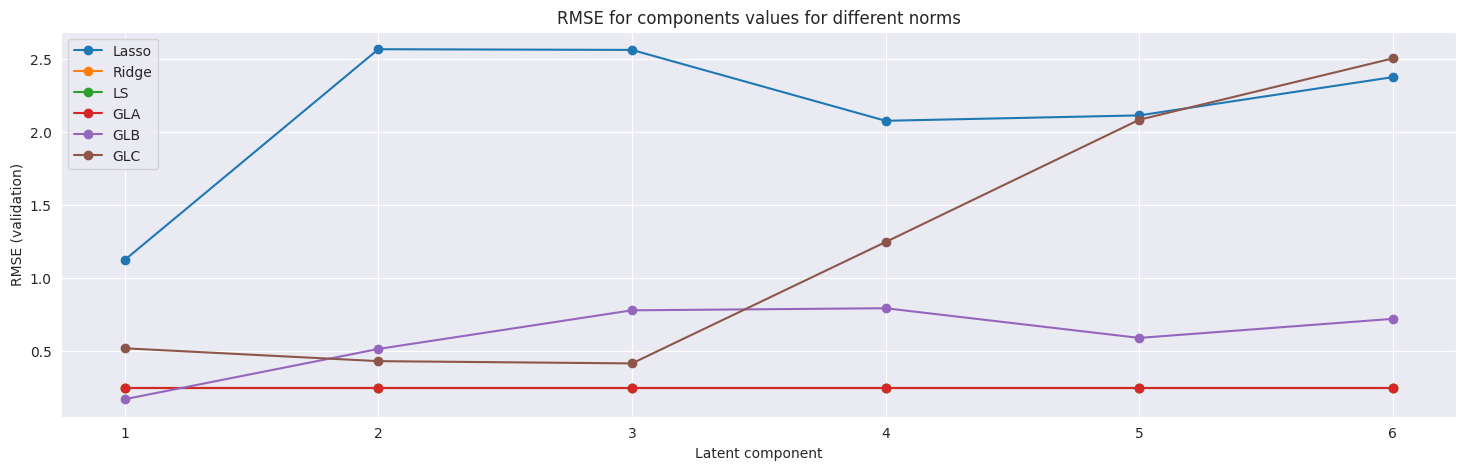

<Figure size 640x480 with 0 Axes>

In [7]:
# RMSE from number of latent components for different norms

"""RMSE seems to be better when n_comp is greater than n_comp=20 and under n_comp=25"""

rmse_curves = {}

for name, model in models.items():
    rmse = []
    for k in range(n_comp):
        Bk = model["Bhat"][:, k]
        intercept = model["intercept"][k]
        y_pred = (X - model["Xmean"]) @ Bk + intercept
        rmse.append(np.sqrt(mean_squared_error(y, y_pred)))
    rmse_curves[name] = np.array(rmse)


plt.figure(figsize=(18,5))

for name, rmse in rmse_curves.items():
    plt.plot(
        range(1, n_comp+1),
        rmse,
        marker="o",
        label=name
    )

plt.xlabel("Latent component")
plt.ylabel("RMSE (validation)")
plt.title("RMSE for components values for different norms")
plt.legend()
plt.show()
plt.tight_layout()

plt.savefig(f"RMSE_vs_latent_components_ncomp_{n_comp}.png")

plt.show()

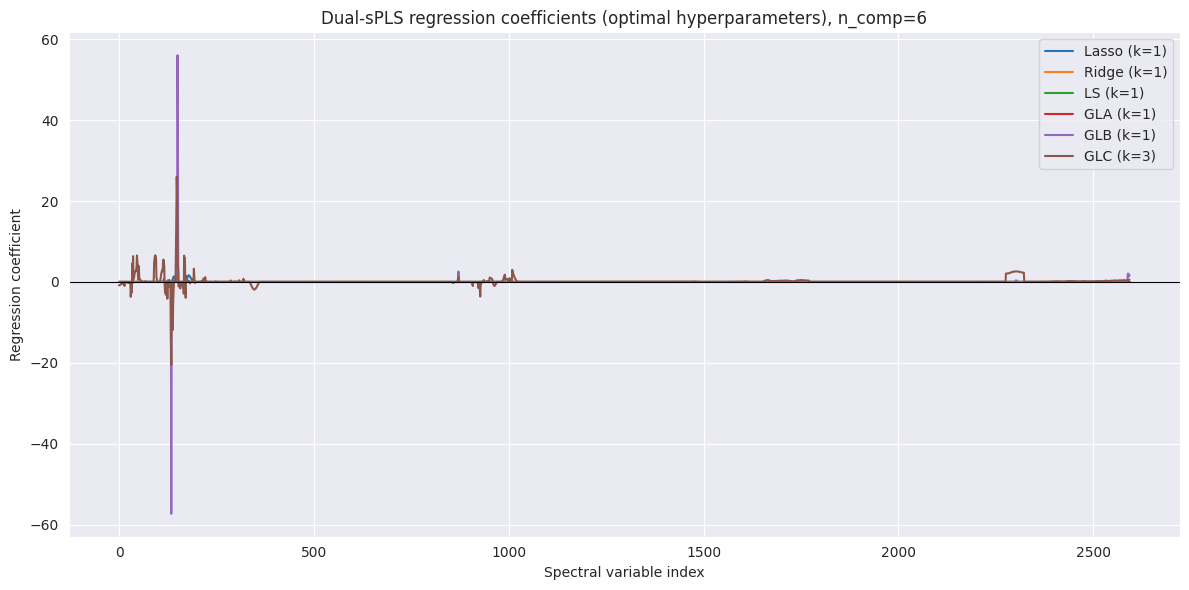

In [8]:
# Coefficients of the regression for all norms

best_components = {
    name: np.argmin(rmse) for name, rmse in rmse_curves.items()
}

plt.figure(figsize=(12,6))

for name, model in models.items():
    k_opt = best_components[name]
    beta = model["Bhat"][:, k_opt]

    plt.plot(
        beta,
        label=f"{name} (k={k_opt+1})",
        linewidth=1.5
    )

plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Spectral variable index")
plt.ylabel("Regression coefficient")
plt.title(f"Dual-sPLS regression coefficients (optimal hyperparameters), n_comp={n_comp}")
plt.legend()
plt.tight_layout()

plt.savefig(f"beta_coeff_ncomp={n_comp}.png")

plt.show()

In [9]:
# Beta coefficients of the regression for differents values of hyperparameter

def plot_coeff_values(
    models,
    model_names,
    X, y,
    n_components,
    ppnu_values,
    indG=None,
    fixed_params=None,
    use_last_component=True,
    cmap_name="viridis"
):
    n_models = len(models)

    fig, axes = plt.subplots(
        n_models, 1,
        figsize=(12, 2.2 * n_models),
        sharex=True
    )

    if n_models == 1:
        axes = [axes]

    cmap = plt.colormaps[cmap_name]
    norm = colors.Normalize(
        vmin=min(ppnu_values),
        vmax=max(ppnu_values)
    )

    for ax, model_fun, name, params in zip(
        axes, models, model_names, fixed_params
    ):
        for ppnu in ppnu_values:
            try:
                kwargs = params.copy()

                if name in ["GLA", "GLB", "GLC"]:
                    kwargs["ppnu"] = np.repeat(ppnu, indG.max())
                    kwargs["indG"] = indG
                else:
                    kwargs["ppnu"] = ppnu

                model = model_fun(
                    X, y,
                    n_components=n_components,
                    **kwargs
                )

                k = -1 if use_last_component else 0
                beta = model["Bhat"][:, k]

                ax.plot(
                    beta,
                    color=cmap(norm(ppnu)),
                    linewidth=1
                )

            except Exception:
                continue

        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(name, loc="left", fontsize=11)
        ax.set_ylabel(r"$\beta$")

        # --- Colorbar proprement attachée ---
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = fig.colorbar(
            sm,
            ax=ax,
            orientation="vertical",
            fraction=0.025,
            pad=0.02
        )
        cbar.set_label(r"$ppnu$")

    axes[-1].set_xlabel("Spectral variable index")

    fig.suptitle(
        f"Dual-sPLS regression coefficients paths\n(color = ppnu), n_comp={n_comp}",
        fontsize=14
    )
    
    plt.tight_layout()

    plt.savefig(f"beta_coeff_ppnu_variation_ncomp={n_comp}.png")
    plt.show()

Dual PLS Lasso ic=1 lambda1=0.0002 mu=1.3464 nu=0.00027792790622243577 nbzeros=26
Dual PLS Lasso ic=2 lambda1=0.0004 mu=0.1601 nu=6.040457392803385e-05 nbzeros=0
Dual PLS Lasso ic=3 lambda1=0.0010 mu=0.0317 nu=3.193993139788113e-05 nbzeros=0
Dual PLS Lasso ic=4 lambda1=0.0001 mu=0.0140 nu=1.21518680546063e-06 nbzeros=0
Dual PLS Lasso ic=5 lambda1=0.0002 mu=0.0099 nu=2.339041965852003e-06 nbzeros=0
Dual PLS Lasso ic=6 lambda1=0.0003 mu=0.0041 nu=1.1390335925188605e-06 nbzeros=0
Dual PLS Lasso ic=1 lambda1=0.0019 mu=1.2992 nu=0.002456580719612598 nbzeros=393
Dual PLS Lasso ic=2 lambda1=0.0047 mu=0.1442 nu=0.0006748561307750514 nbzeros=218
Dual PLS Lasso ic=3 lambda1=0.0102 mu=0.0236 nu=0.00024140377904704322 nbzeros=47
Dual PLS Lasso ic=4 lambda1=0.0025 mu=0.0116 nu=2.8498563325146818e-05 nbzeros=0
Dual PLS Lasso ic=5 lambda1=0.0045 mu=0.0099 nu=4.490587224112015e-05 nbzeros=0
Dual PLS Lasso ic=6 lambda1=0.0037 mu=0.0034 nu=1.2649131763075562e-05 nbzeros=0
Dual PLS Lasso ic=1 lambda1=0.0

/home/alexis/python/Dual-sPLS/src/dual_spls/lasso.py:61: RuntimeWarning: divide by zero encountered in scalar divide
  _lambda = nu/mu
/home/alexis/python/Dual-sPLS/src/dual_spls/lasso.py:64: RuntimeWarning: invalid value encountered in scalar divide
  scaling_factor = mu / (nu * z_nu_1 + mu**2) # Scaling factor, see theory


Dual PLS Ridge ic=1 lambda1=0.0002 mu=1.3462 nu2=0.001 nbzeros=26
Dual PLS Ridge ic=2 lambda1=0.0004 mu=0.1601 nu2=0.001 nbzeros=0
Dual PLS Ridge ic=3 lambda1=0.0010 mu=0.0317 nu2=0.001 nbzeros=0
Dual PLS Ridge ic=4 lambda1=0.0001 mu=0.0140 nu2=0.001 nbzeros=0
Dual PLS Ridge ic=5 lambda1=0.0002 mu=0.0099 nu2=0.001 nbzeros=0
Dual PLS Ridge ic=6 lambda1=0.0003 mu=0.0041 nu2=0.001 nbzeros=0
Dual PLS Ridge ic=1 lambda1=0.0019 mu=1.2990 nu2=0.001 nbzeros=393
Dual PLS Ridge ic=2 lambda1=0.0047 mu=0.1442 nu2=0.001 nbzeros=218
Dual PLS Ridge ic=3 lambda1=0.0102 mu=0.0236 nu2=0.001 nbzeros=47
Dual PLS Ridge ic=4 lambda1=0.0025 mu=0.0116 nu2=0.001 nbzeros=0
Dual PLS Ridge ic=5 lambda1=0.0045 mu=0.0099 nu2=0.001 nbzeros=0
Dual PLS Ridge ic=6 lambda1=0.0037 mu=0.0034 nu2=0.001 nbzeros=0
Dual PLS Ridge ic=1 lambda1=0.0039 mu=1.2543 nu2=0.001 nbzeros=760
Dual PLS Ridge ic=2 lambda1=0.0111 mu=0.1270 nu2=0.001 nbzeros=543
Dual PLS Ridge ic=3 lambda1=0.0159 mu=0.0201 nu2=0.001 nbzeros=414
Dual PLS Ridg

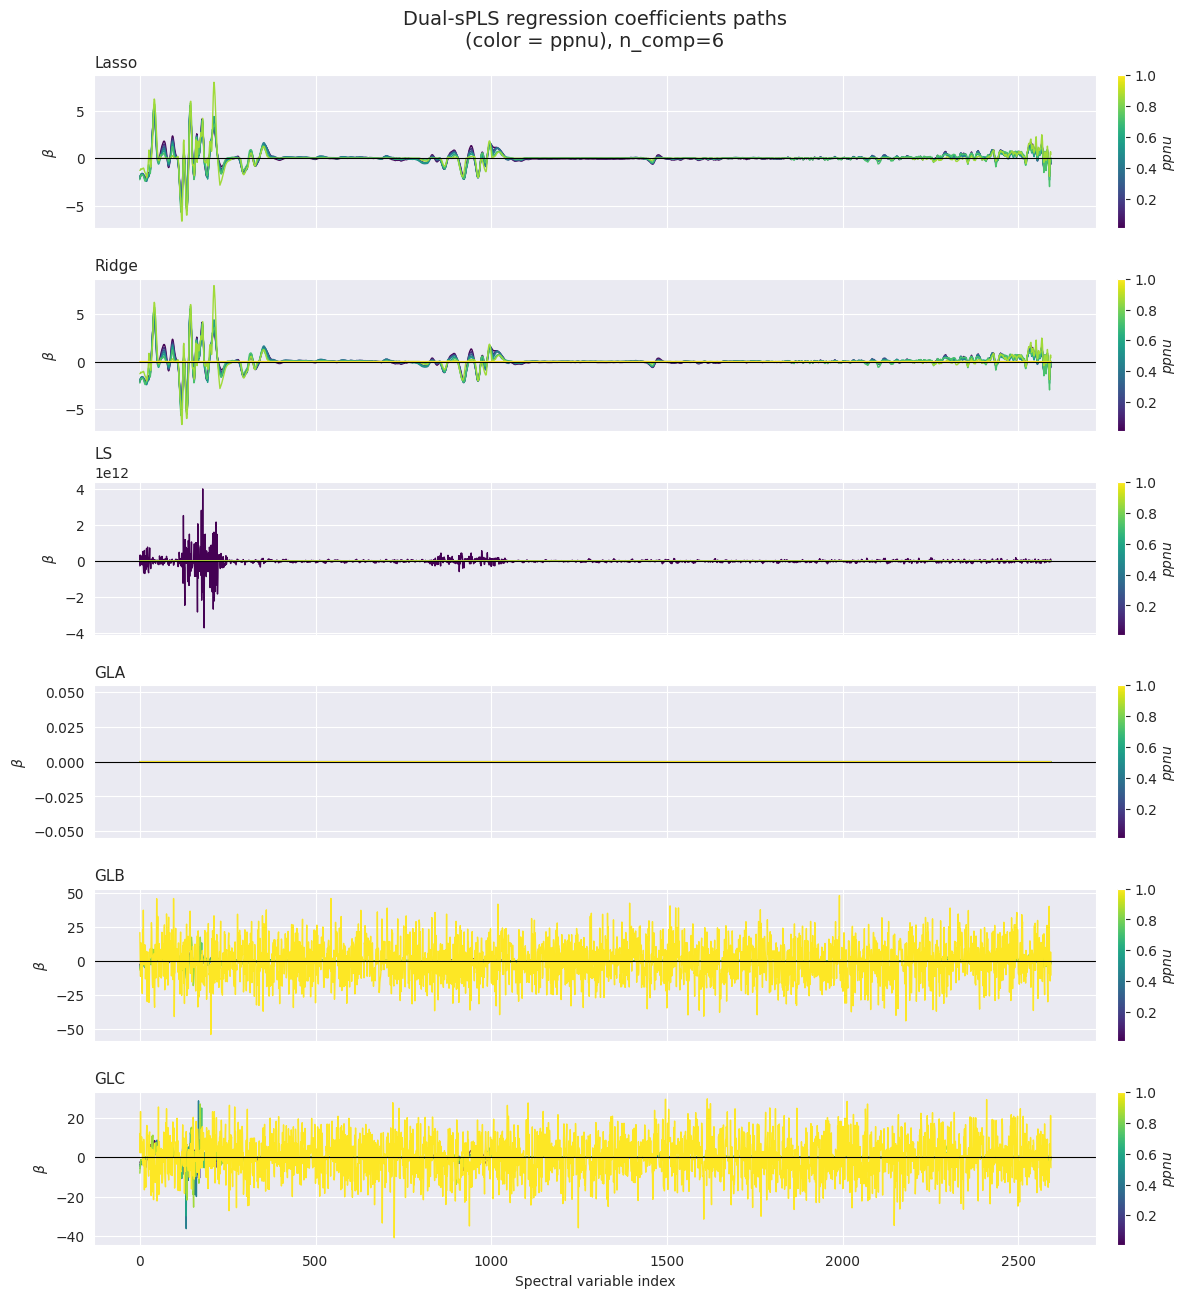

In [10]:
# Params
ppnu_values = np.linspace(0.01, 1.0, 8)

models = [
    dual_spls_lasso,
    d_spls_ridge,
    d_spls_ls,
    dual_spls_gla_random,
    dual_spls_glb,
    dual_spls_glc
]

model_names = ["Lasso", "Ridge", "LS", "GLA", "GLB", "GLC"]

fixed_params = [
    {},                         # Lasso
    {"nu2": 0.001},             # Ridge
    {},                         # LS
    {"verbose": False},         # GLA
    {"verbose": False},         # GLB
    {                           # GLC
        "gamma": np.repeat(1.0 / nG, nG),
        "verbose": False
    }
]

plot_coeff_values(
    models=models,
    model_names=model_names,
    X=X,
    y=y,
    n_components=n_comp,
    ppnu_values=ppnu_values,
    indG=indG,
    fixed_params=fixed_params
)